In [1]:
import pandas as pd
import os
import sys
import seaborn as sns
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
sys.path.append(os.path.abspath(".."))
from scripts.utils import make_engine
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

In [2]:
# create engine
engine = make_engine()

# read SQL query
BASE_DIR = Path.cwd().parent
sql_query = BASE_DIR / "queries" / "recency.sql"
with open(sql_query, "r") as file:
    sql_query = file.read()

# get df
df = pd.read_sql_query(sql_query, con=engine)

df


,customer_id,days_since_last_order
0,C0001,587
1,C0002,93
2,C0003,374
3,C0004,92
4,C0005,589
...,...,...
433,C0496,43
434,C0497,502
435,C0498,362
436,C0499,139


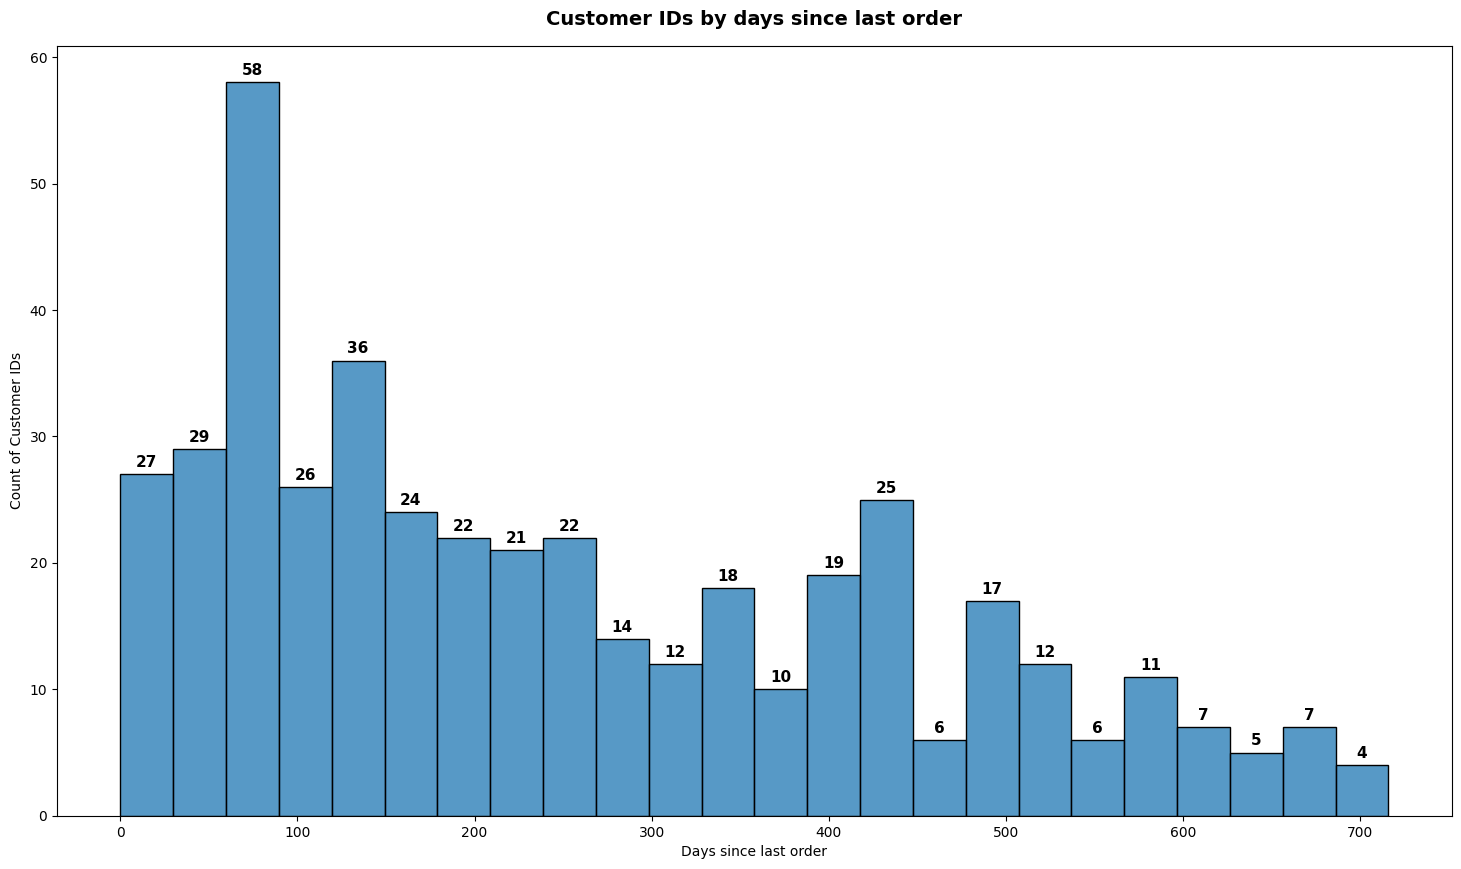

In [3]:
plt.figure(figsize=(18,10))
ax = sns.histplot(data=df, x="days_since_last_order", bins=24)
plt.title("Customer IDs by days since last order", fontsize=14, fontweight='bold', pad=15)
ax.bar_label(ax.containers[0], fontsize=11, fontweight='bold', padding=3)
plt.xlabel("Days since last order")
plt.ylabel("Count of Customer IDs")
plt.show()

In [4]:
frequency_query = "SELECT customer_id, COUNT(order_id) AS total_orders FROM orders GROUP BY customer_id" 
df2 = pd.read_sql_query(frequency_query, con=engine)

df2_figprep = df2.groupby("total_orders")["customer_id"].count().reset_index()
df2_figprep["percentage"] = (df2_figprep["customer_id"] / df2_figprep["customer_id"].sum()) * 100

df2

,customer_id,total_orders
0,C0001,1
1,C0002,2
2,C0003,3
3,C0004,2
4,C0005,1
...,...,...
449,C0496,3
450,C0497,2
451,C0498,2
452,C0499,1


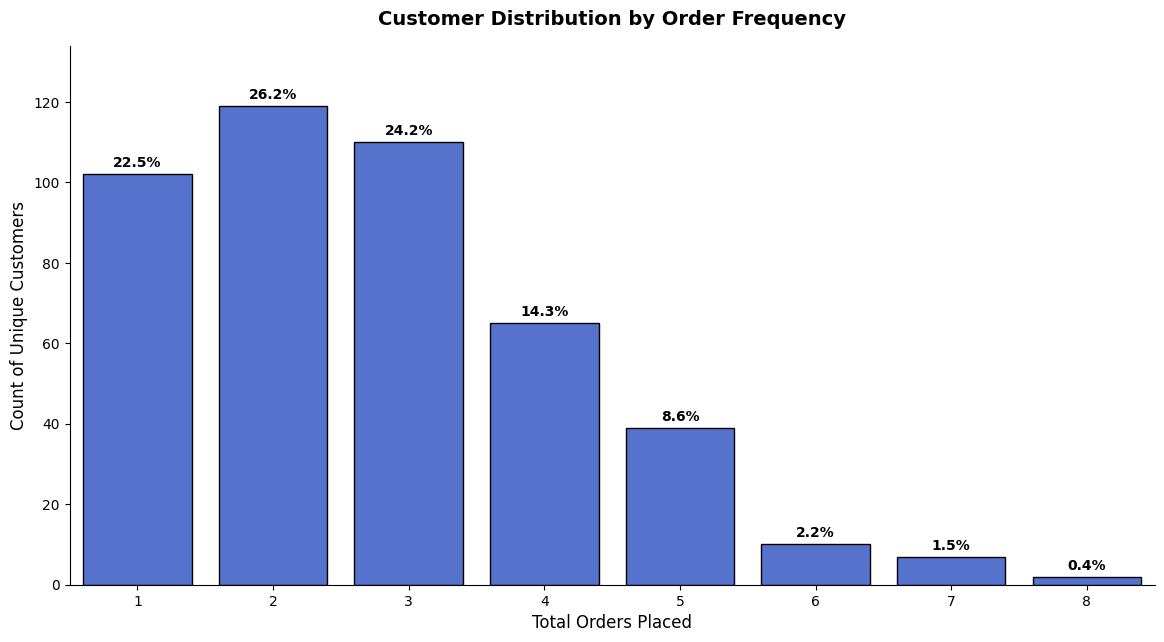

In [5]:
plt.figure(figsize=(14, 7))
ax = sns.barplot(data=df2_figprep, x="total_orders", y="customer_id", color="royalblue", edgecolor="black")

# Add the percentage labels on top of each bar
for p in ax.patches:
    height = p.get_height()
    percentage = (height / df2_figprep["customer_id"].sum()) * 100
    ax.annotate(f'{percentage:.1f}%', 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='center', 
                xytext=(0, 8), 
                textcoords='offset points',
                fontweight='bold')

plt.title("Customer Distribution by Order Frequency", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Total Orders Placed", fontsize=12)
plt.ylabel("Count of Unique Customers", fontsize=12)
plt.ylim(0, df2_figprep["customer_id"].max() + 15) 
sns.despine() 

In [6]:
monetary_query = """
    SELECT 
    customer_id,
    SUM(final_amount) AS total_spend,
    AVG(final_amount) AS average_order_value,
    MAX(final_amount) AS max_single_order
    FROM orders
    WHERE order_status = 'Delivered'
    GROUP BY customer_id
    """

df3 = pd.read_sql_query(monetary_query, con=engine)
df3

,customer_id,total_spend,average_order_value,max_single_order
0,C0001,997.50,997.500000,997.50
1,C0002,1226.30,613.150000,853.20
2,C0003,1854.30,618.100000,754.65
3,C0004,713.05,713.050000,713.05
4,C0005,2047.25,2047.250000,2047.25
...,...,...,...,...
433,C0496,3373.50,1124.500000,1627.25
434,C0497,948.10,948.100000,948.10
435,C0498,2727.20,1363.600000,1369.75
436,C0499,423.25,423.250000,423.25


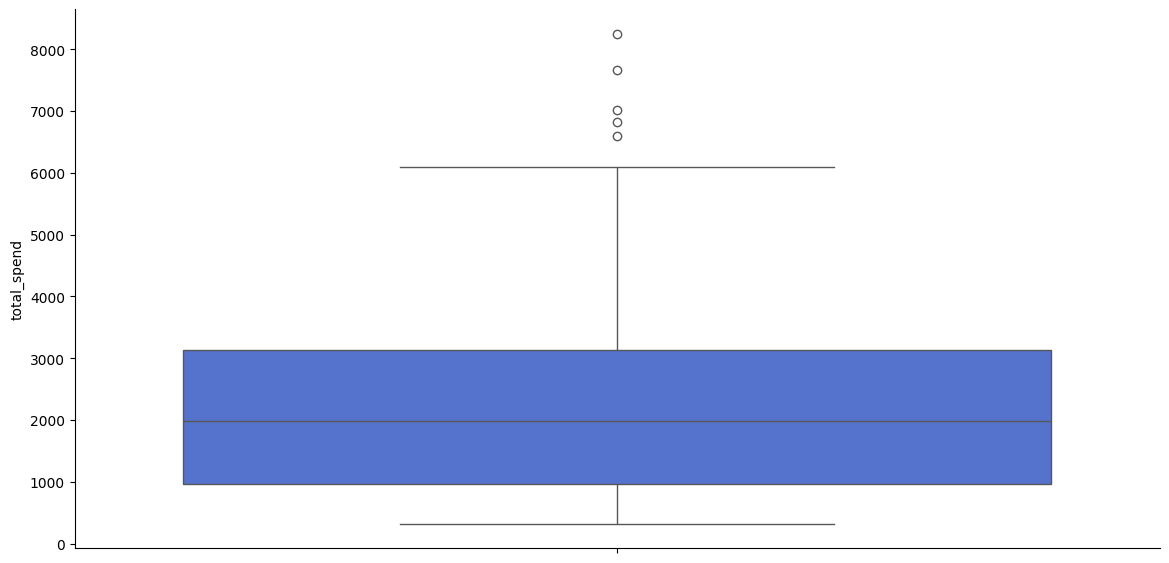

In [7]:
plt.figure(figsize=(14, 7))
sns.boxplot(data=df3, y="total_spend", color="royalblue")
sns.despine()
plt.show()

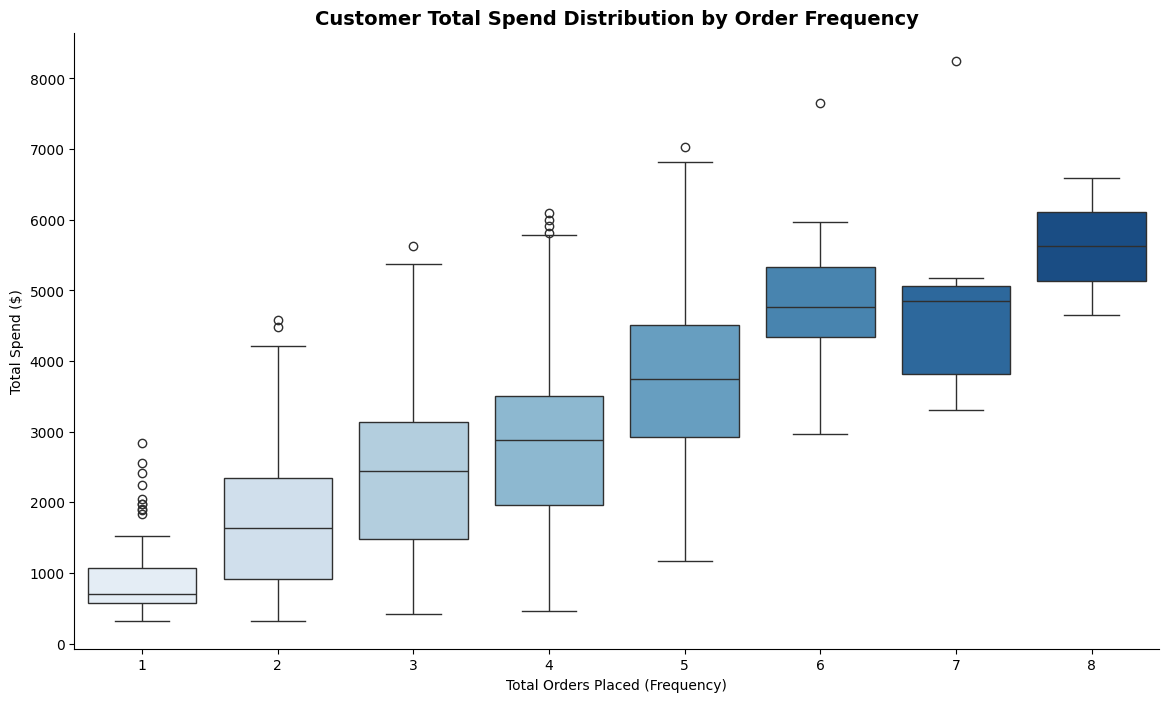

In [8]:
# merge df2 and df3
df_merged = pd.merge(df2, df3, on="customer_id")

plt.figure(figsize=(14, 8))

# Plotting boxplot
sns.boxplot(data=df_merged, x="total_orders", y="total_spend", palette="Blues")

plt.title("Customer Total Spend Distribution by Order Frequency", fontsize=14, fontweight='bold')
plt.xlabel("Total Orders Placed (Frequency)")
plt.ylabel("Total Spend ($)")
sns.despine()

plt.show()